# Phase 2 โ€” Feature Extraction

**Goal:** Extract and verify MFCC and Wav2Vec2 features, then visualize their discriminability across emotion classes.

## Steps
1. Run full extraction pipeline
2. Verify shapes and distributions
3. MFCC heatmap per emotion
4. Wav2Vec2 embedding PCA / t-SNE
5. Feature statistics for drift baseline

In [3]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')
FEATURES_DIR = Path('../data/features')
EXPORTS_DIR  = Path('../data/monitoring_exports')

## 1. Run Feature Extraction

Run this cell **once** to extract all features.  
- MFCC only: ~2 min  
- Full (Wav2Vec2): ~30-60 min CPU, ~5 min GPU

In [4]:
from src.feature_extraction import run_extraction

run_extraction(
    audio_dir='../data/raw',
    features_dir='../data/features',
    config_path='../configs/config.yaml',
    extract_wav2vec2=True,  # set False to skip Wav2Vec2
)

# Or from terminal (run from project root):
# python src/feature_extraction.py
# python src/feature_extraction.py --no_wav2vec2

Scanning audio from: ../data/raw
  Total: 1440 files | Train: 1152 | Test: 288

Extracting MFCC features ...


  0%|          | 0/1440 [00:00<?, ?it/s]

100%|██████████| 1440/1440 [00:09<00:00, 148.37it/s]


  MFCC features: (1440, 240)


c:\Users\nong9\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


Loading Wav2Vec2 (facebook/wav2vec2-base) on cuda ...


c:\Users\nong9\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(



Extracting Wav2Vec2 embeddings ...


100%|██████████| 1440/1440 [00:18<00:00, 76.53it/s]

  Wav2Vec2 features: (1440, 768)

All features saved to: ..\data\features/


## 2. Load and Verify Features

In [5]:
mfcc     = np.load(FEATURES_DIR / 'mfcc_features.npy')
labels   = np.load(FEATURES_DIR / 'labels.npy')
metadata = pd.read_csv(FEATURES_DIR / 'metadata.csv')

with open(FEATURES_DIR / 'label_map.json') as f:
    label_map = json.load(f)

idx2label = {v: k for k, v in label_map.items()}
emotion_names = [idx2label[i] for i in labels]

print(f'MFCC shape:   {mfcc.shape}')
print(f'Labels shape: {labels.shape}')
print(f'\nEmotion counts:')
print(pd.Series(emotion_names).value_counts())

w2v_path = FEATURES_DIR / 'wav2vec2_features.npy'
if w2v_path.exists():
    w2v = np.load(w2v_path)
    print(f'\nWav2Vec2 shape: {w2v.shape}')
else:
    w2v = None
    print('\nWav2Vec2 features not yet extracted.')

MFCC shape:   (1440, 240)
Labels shape: (1440,)

Emotion counts:
angry        192
calm         192
disgust      192
fearful      192
happy        192
sad          192
surprised    192
neutral       96
Name: count, dtype: int64

Wav2Vec2 shape: (1440, 768)


## 3. MFCC Mean per Emotion (Heatmap)

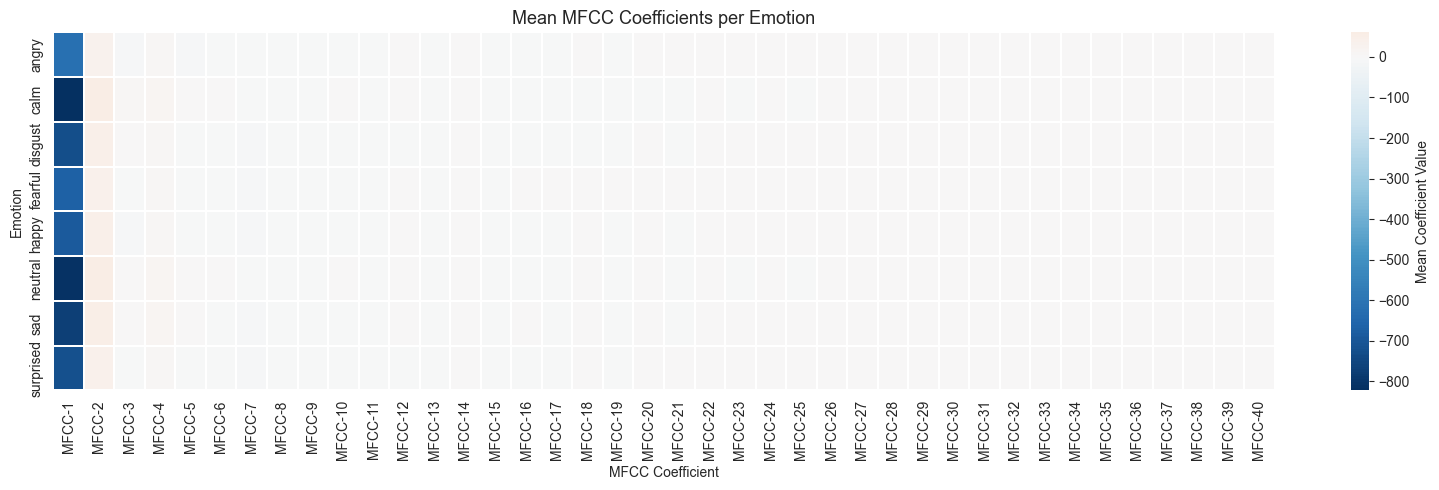

In [6]:
mfcc_means = mfcc[:, :40]

emotion_mfcc = pd.DataFrame(mfcc_means)
emotion_mfcc['emotion'] = emotion_names
emotion_avg = emotion_mfcc.groupby('emotion').mean()
emotion_avg.columns = [f'MFCC-{i+1}' for i in range(40)]

plt.figure(figsize=(16, 5))
sns.heatmap(emotion_avg, cmap='RdBu_r', center=0,
            linewidths=0.3, cbar_kws={'label': 'Mean Coefficient Value'})
plt.title('Mean MFCC Coefficients per Emotion', fontsize=13)
plt.xlabel('MFCC Coefficient')
plt.ylabel('Emotion')
plt.tight_layout()
plt.savefig(EXPORTS_DIR / 'feature_mfcc_heatmap.png', dpi=120)
plt.show()

## 4. PCA of MFCC Features

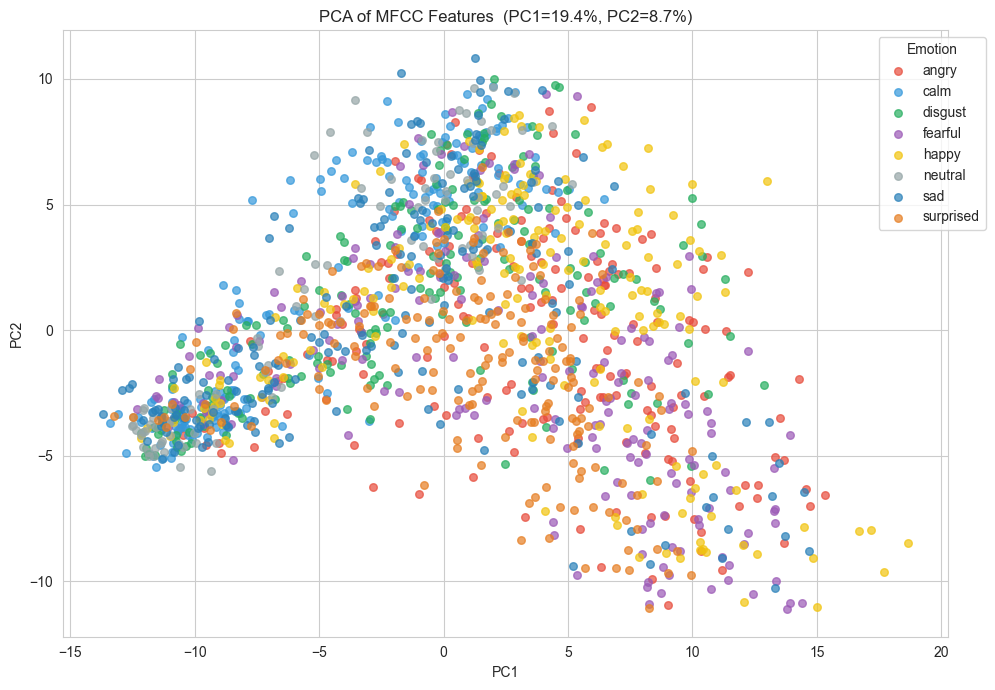

In [7]:
COLORS = {
    'neutral': '#95a5a6', 'calm':     '#3498db',
    'happy':   '#f1c40f', 'sad':      '#2980b9',
    'angry':   '#e74c3c', 'fearful':  '#9b59b6',
    'disgust': '#27ae60', 'surprised':'#e67e22'
}

scaler = StandardScaler()
mfcc_scaled = scaler.fit_transform(mfcc)

pca = PCA(n_components=2, random_state=42)
mfcc_pca = pca.fit_transform(mfcc_scaled)

plt.figure(figsize=(10, 7))
for emo in sorted(set(emotion_names)):
    mask = np.array(emotion_names) == emo
    plt.scatter(mfcc_pca[mask, 0], mfcc_pca[mask, 1],
                label=emo, color=COLORS[emo], alpha=0.7, s=30)
plt.legend(title='Emotion', bbox_to_anchor=(1.05, 1))
plt.title(
    f'PCA of MFCC Features  '
    f'(PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%})'
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.savefig(EXPORTS_DIR / 'feature_mfcc_pca.png', dpi=120)
plt.show()

## 5. t-SNE of Wav2Vec2 Embeddings

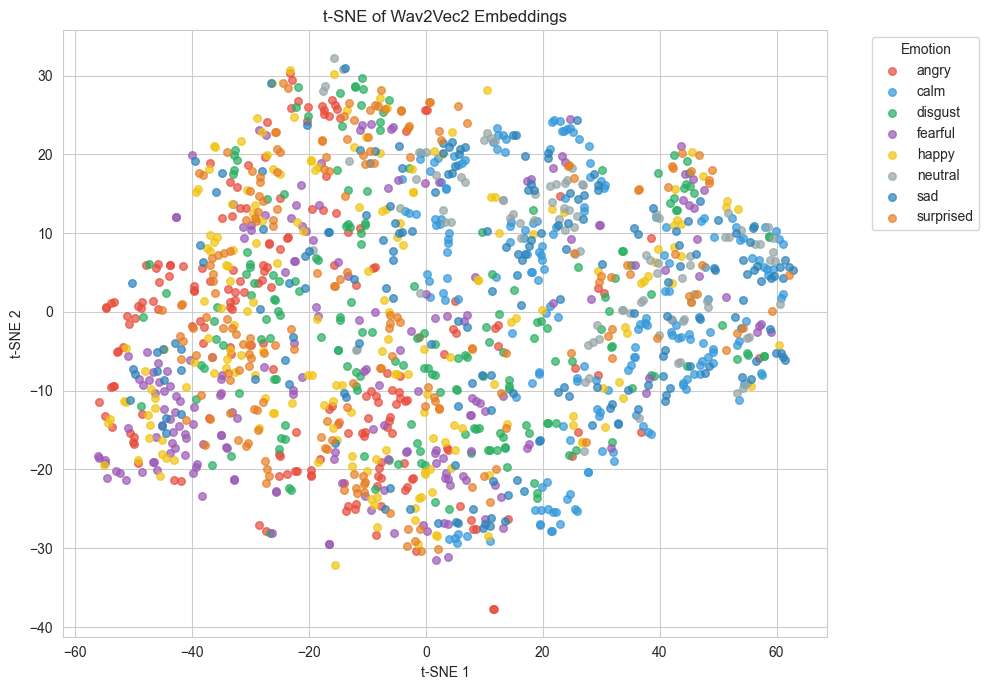

In [9]:
if w2v is not None:
    w2v_scaled = StandardScaler().fit_transform(w2v)
    w2v_pca50  = PCA(n_components=50, random_state=42).fit_transform(w2v_scaled)
    tsne       = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
    w2v_tsne   = tsne.fit_transform(w2v_pca50)

    plt.figure(figsize=(10, 7))
    for emo in sorted(set(emotion_names)):
        mask = np.array(emotion_names) == emo
        plt.scatter(w2v_tsne[mask, 0], w2v_tsne[mask, 1],
                    label=emo, color=COLORS[emo], alpha=0.7, s=30)
    plt.legend(title='Emotion', bbox_to_anchor=(1.05, 1))
    plt.title('t-SNE of Wav2Vec2 Embeddings')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.tight_layout()
    plt.savefig(EXPORTS_DIR / 'feature_wav2vec2_tsne.png', dpi=120)
    plt.show()
else:
    print('Wav2Vec2 features not available. Run with extract_wav2vec2=True.')

## 6. Feature Statistics (drift baseline for Phase 4)

In [10]:
train_mask  = metadata['split'] == 'train'
mfcc_train  = mfcc[train_mask.values]

feature_stats = pd.DataFrame({
    'feature': [f'mfcc_{i}' for i in range(mfcc.shape[1])],
    'mean':    mfcc_train.mean(axis=0),
    'std':     mfcc_train.std(axis=0),
    'min':     mfcc_train.min(axis=0),
    'max':     mfcc_train.max(axis=0),
})
feature_stats.to_csv(EXPORTS_DIR / 'reference_feature_stats.csv', index=False)
print(f'Saved reference feature stats: {feature_stats.shape}')
feature_stats.head(10)

Saved reference feature stats: (240, 5)


,feature,mean,std,min,max
0,mfcc_0,-724.960510,100.896942,-958.721680,-434.986908
1,mfcc_1,47.027004,17.015022,-10.853686,92.711021
2,mfcc_2,-2.357951,12.204227,-48.159744,33.660015
3,mfcc_3,11.844856,9.164710,-15.753612,38.406311
4,mfcc_4,-3.181060,9.043644,-30.379881,18.218904
5,mfcc_5,-2.873647,6.743350,-26.872995,17.978651
6,mfcc_6,-8.148539,6.260528,-23.172291,7.715090
7,mfcc_7,-6.310041,4.913177,-26.741037,9.115855
8,mfcc_8,-3.097758,4.549357,-20.923561,22.310221
9,mfcc_9,-2.112997,5.057222,-15.701341,17.523960
